# Rotating Cylinders Benchmark (Taylor-Couette Flow) — Provenance Plots

This notebook fetches rotating-cylinders benchmark provenance data from RoHub and visualises convergence for Taylor-Couette flow simulations.

Each series in the plots corresponds to one simulation tool. The x-axis uses the number of radial cells, while the y-axis shows the relative L2 error for pressure or velocity on a logarithmic scale.

## Setup

Import the RoHub query helpers and shared plotting utilities from the `provenance` package.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

provenance_path = os.path.abspath(os.path.join("..", "provenance"))

if provenance_path not in sys.path:
    sys.path.append(provenance_path)

from rohub_provenance import (
    configure_rohub,
    find_annotated_ro_uuids,
    find_named_graphs_for_uuids,
    query_metric_data_from_named_graphs,
    get_current_code_repository_url,
)
from plot_metrics import select_plot_columns, plot_provenance_graph

## Configuration

In [2]:
BENCHMARK_NAME = "rotating-cylinders"
USE_PRODUCTION_ROHUB = True  # set to False to use the development RoHub instance

## Connect to RoHub and find RO-Crates

Configure the RoHub client and look up all RO-Crates that are annotated with this benchmark and the current branch of the code repository.
Each RO-Crate corresponds to one simulation run and contains the recorded parameters and metrics.

In [3]:
configure_rohub(use_production_rohub=USE_PRODUCTION_ROHUB)

code_repository_url = get_current_code_repository_url(BENCHMARK_NAME)
print(f"Searching for RO-Crates annotated with: {code_repository_url}")

uuids = find_annotated_ro_uuids(BENCHMARK_NAME, code_repository_url=code_repository_url)
print(f"Found {len(uuids)} RO-Crate(s)")

Searching for RO-Crates annotated with: https://github.com/Simulation-Benchmarks/rotating-cylinders/tree/finish_rocrate
Found 2 RO-Crate(s)


## Resolve SPARQL named graphs

Each RO-Crate is stored in a dedicated named graph in the RoHub triple store.
Resolving the UUIDs to graph URIs allows the subsequent data query to target only the relevant graphs.

In [4]:
named_graphs = find_named_graphs_for_uuids(uuids, use_production_rohub=USE_PRODUCTION_ROHUB)

print(f"Resolved {len(named_graphs)} named graph(s):")
for uuid, graph_uri in named_graphs.items():
    print(f"  {uuid}\n    -> {graph_uri}")

Resolved 2 named graph(s):
  b9bdf11b-d99c-4c34-91af-ddec9e6d80e1
    -> https://w3id.org/ro-id/b9bdf11b-d99c-4c34-91af-ddec9e6d80e1/.ro/annotations/255af35e-296f-4a1c-b2f3-d4a72702f02c.ttl
  878a7db7-b54c-4797-9d74-59bb18987102
    -> https://w3id.org/ro-id/878a7db7-b54c-4797-9d74-59bb18987102/.ro/annotations/d704f561-acad-4f2d-b303-abe63279b92a.ttl


## Fetch simulation results

Query the named graphs for the simulation parameters and result metrics.
The result is a pandas DataFrame where each row is one simulation run.

In [5]:
parameters = ["cells_radial"]
metrics = ["l2_error_pressure_rel", "l2_error_velocity_rel"]

data = query_metric_data_from_named_graphs(
    parameters=parameters,
    metrics=metrics,
    named_graphs=list(named_graphs.values()),
)

## Relative L2 Pressure Error

Plot the relative L2 pressure error against the number of radial cells. Lower values indicate closer agreement with the analytical circular Couette-flow reference.

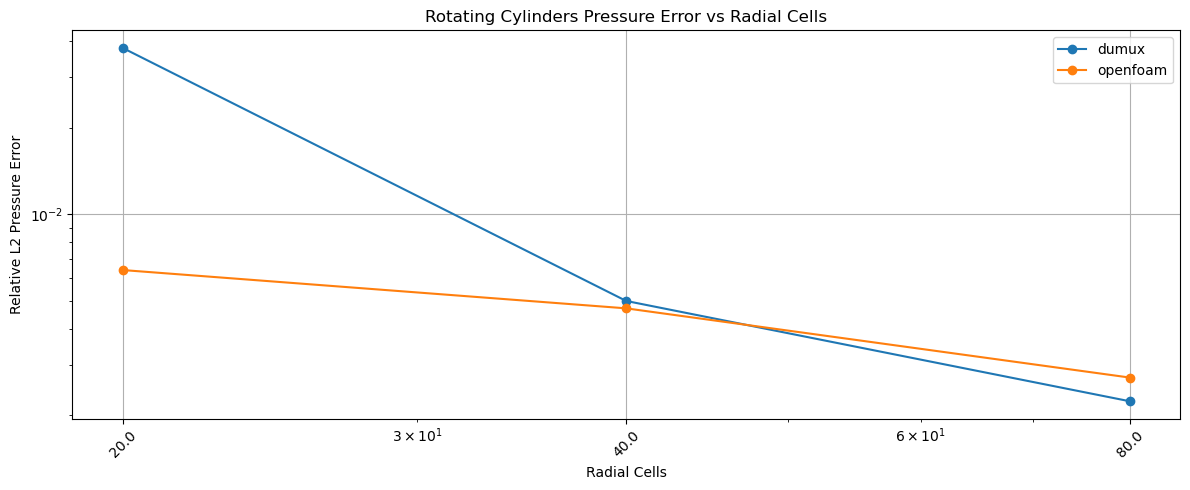

In [6]:
plot_df = select_plot_columns(
    data,
    parameters=["cells_radial"],
    metrics=["l2_error_pressure_rel"],
)

plot_provenance_graph(
    data=plot_df.values.tolist(),
    x_axis_label="Radial Cells",
    y_axis_label="Relative L2 Pressure Error",
    title="Rotating Cylinders Pressure Error vs Radial Cells",
    log_y=True,
)

## Relative L2 Velocity Error

Plot the relative L2 velocity error against the number of radial cells. The log-log view makes the convergence trend visible as the mesh is refined.

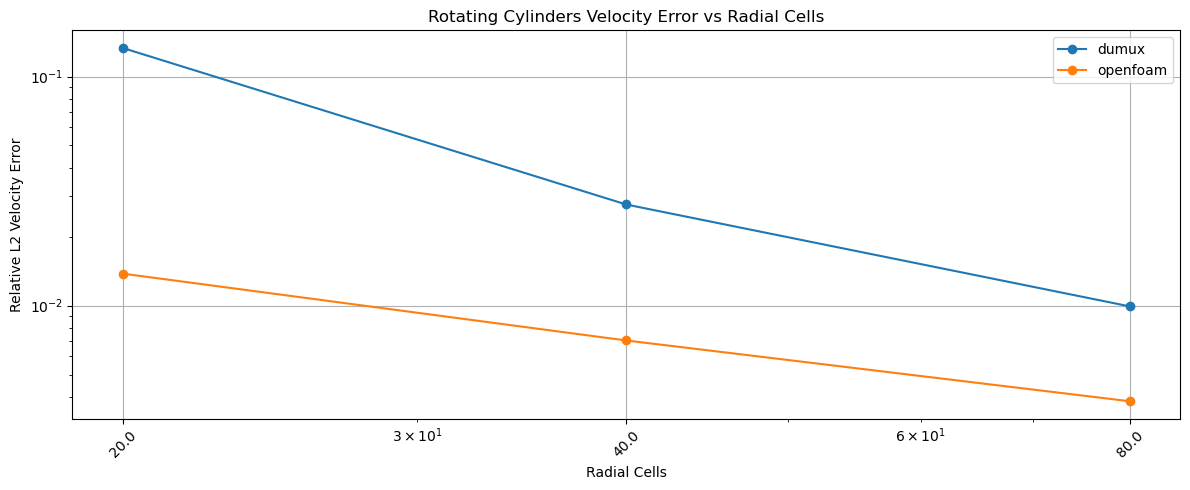

In [7]:
plot_df = select_plot_columns(
    data,
    parameters=["cells_radial"],
    metrics=["l2_error_velocity_rel"],
)

plot_provenance_graph(
    data=plot_df.values.tolist(),
    x_axis_label="Radial Cells",
    y_axis_label="Relative L2 Velocity Error",
    title="Rotating Cylinders Velocity Error vs Radial Cells",
    log_y=True,
)

## Pressure and Velocity Convergence

Show pressure and velocity errors together for each simulation tool.

In [ ]:
convergence_df = data.loc[:, [
    "tool_name",
    "cells_radial",
    "l2_error_pressure_rel",
    "l2_error_velocity_rel",
]].copy()

for column in ["cells_radial", "l2_error_pressure_rel", "l2_error_velocity_rel"]:
    convergence_df[column] = pd.to_numeric(convergence_df[column], errors="coerce")

convergence_df = convergence_df.dropna().sort_values(["tool_name", "cells_radial"])

fig, ax = plt.subplots(figsize=(10, 6))

for tool_name, tool_df in convergence_df.groupby("tool_name"):
    tool_df = tool_df.sort_values("cells_radial")
    ax.plot(
        tool_df["cells_radial"],
        tool_df["l2_error_pressure_rel"],
        marker="o",
        linewidth=1.5,
        label=f"{tool_name} pressure",
    )
    ax.plot(
        tool_df["cells_radial"],
        tool_df["l2_error_velocity_rel"],
        marker="s",
        linestyle="--",
        linewidth=1.5,
        label=f"{tool_name} velocity",
    )

x_ticks = sorted(convergence_df["cells_radial"].unique())
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radial Cells")
ax.set_ylabel("Relative L2 Error")
ax.set_title("Rotating Cylinders Pressure and Velocity Convergence")
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(x) for x in x_ticks])
ax.grid(True, which="both", linestyle="-", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()